# Planning-Agent Ablation Study

This notebook runs a reproducible `2^3` factorial ablation on the planning agent integrations for:

- `protocol_search_sop`
- `literature_search_pubmed`
- `episodic_memory`

Methods:
- **Factorial design**: all 8 combinations of protocol search, literature search, and episodic memory.
- **Planner output**: generated as a structured `PlanningPlan` Pydantic object.
- **Evaluation**: each plan is scored by an LLM judge that returns a structured `PlanJudgement` object.
- **Benchmark tasks**: AML prioritization, COVID-19 primary-screen reprioritization, MSD repurposing, and COVID-19 validation planning (maybe more)


In [ ]:
import sys
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time 


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR
while PROJECT_ROOT != PROJECT_ROOT.parent and not ((PROJECT_ROOT / "app").is_dir() and (PROJECT_ROOT / "backend").is_dir()):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not ((PROJECT_ROOT / "app").is_dir() and (PROJECT_ROOT / "backend").is_dir()):
    raise RuntimeError(f"Could not locate project root from {CURRENT_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

ABLATION_DIR = PROJECT_ROOT / "analysis" / "Ablation"
OUTPUT_DIR = ABLATION_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from ablation_utils import run_condition, nonparametric_config_tests

# Run ablation study

In [ ]:
# Load request dataset
TASKS_df = pd.read_csv('planning_requests.csv')
TASKS = TASKS_df.to_dict(orient='records')

# 2^3 factorial config
CONDITIONS = [
    {
        "use_protocol": protocol,
        "use_literature": literature,
        "use_episodic": episodic,
        "config_label": f"P{protocol}-L{literature}-E{episodic}",
    }
    for protocol, literature, episodic in product([0, 1], repeat=3)
]

N_REPEATS = 10
rows = []

for run_idx in range(9, N_REPEATS + 1):
    print(f"\n=== Repeat {run_idx}/{N_REPEATS} ===")
    for task in TASKS:
        for condition in CONDITIONS:
            print(f"Running {task['task_id']} | {condition['config_label']} | repeat={run_idx}")
            result = run_condition(
                task,
                use_protocol=condition["use_protocol"],
                use_literature=condition["use_literature"],
                use_episodic=condition["use_episodic"],
            )
            judgement = result["judgement"]
            rows.append(
                {
                    **condition,
                    "run_id": run_idx,
                    "task_id": task["task_id"],
                    "request": task["request"],
                    "plan_text": result["plan_text"],
                    "plan_json": result["plan_json"],
                    "judgement_json": result["judgement_json"],
                    "quality_score": result["quality_score"],
                    "structure_completeness": judgement.structure_completeness.score / 5.0,
                    "task_alignment": judgement.task_alignment.score / 5.0,
                    "executability": judgement.executability.score / 5.0,
                    "scientific_rigor": judgement.scientific_rigor.score / 5.0,
                    "context_use": judgement.context_use.score / 5.0,
                    "specificity": judgement.specificity.score / 5.0,
                    "overall_quality": judgement.overall_quality.score / 5.0,
                    "protocol_query": result["protocol_query"],
                    "literature_query": result["literature_query"],
                    "episodic_examples_used": result["episodic_examples_used"],
                }
            )
        time.sleep(1)

results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR / "ablation_raw_results.csv", index=False)
results_df[
    [
        "run_id",
        "task_id",
        "config_label",
        "quality_score",
        "task_alignment",
        "executability",
        "scientific_rigor",
        "context_use",
        "specificity",
    ]
].sort_values(["run_id", "task_id", "config_label"]).head(24)


# Summary results for each configuration

In [62]:
import scipy.stats as stats

def ci95(x):
    n = len(x)
    if n < 2:
        return 0
    return stats.sem(x) * stats.t.ppf(0.975, df=n - 1)

summary_df = (
    results_df.groupby(["config_label", "use_protocol", "use_literature", "use_episodic"], as_index=False)
    .agg(
        n_samples=("quality_score", "size"),
        quality_score=("quality_score", "mean"),
        quality_score_ci95=("quality_score", ci95),
        task_alignment=("task_alignment", "mean"),
        executability=("executability", "mean"),
        scientific_rigor=("scientific_rigor", "mean"),
        context_use=("context_use", "mean"),
        specificity=("specificity", "mean"),
        overall_quality=("overall_quality", "mean"),
        episodic_examples_used=("episodic_examples_used", "mean"),
    )
)


summary_df.to_csv(OUTPUT_DIR / "ablation_summary_by_config.csv", index=False)
summary_df


,config_label,use_protocol,use_literature,use_episodic,n_samples,quality_score,quality_score_ci95,task_alignment,executability,scientific_rigor,context_use,specificity,overall_quality,episodic_examples_used
0,P0-L0-E0,0,0,0,150,0.492222,0.007357,0.440000,0.509333,0.584000,0.376000,0.404000,0.440000,0.0
1,P0-L0-E1,0,0,1,150,0.558444,0.009791,0.553333,0.552000,0.612000,0.441333,0.468000,0.525333,2.0
2,P0-L1-E0,0,1,0,150,0.546667,0.010238,0.540000,0.492000,0.600000,0.546667,0.437333,0.476000,0.0
3,P0-L1-E1,0,1,1,150,0.622000,0.009487,0.597333,0.566667,0.629333,0.652000,0.521333,0.581333,2.0
4,P1-L0-E0,1,0,0,150,0.530000,0.007924,0.526667,0.525333,0.593333,0.434667,0.414667,0.488000,0.0
5,P1-L0-E1,1,0,1,150,0.611111,0.010079,0.604000,0.580000,0.602667,0.598667,0.508000,0.576000,2.0
6,P1-L1-E0,1,1,0,150,0.601556,0.010635,0.598667,0.544000,0.620000,0.621333,0.482667,0.550667,0.0
7,P1-L1-E1,1,1,1,150,0.651333,0.006928,0.604000,0.597333,0.621333,0.725333,0.562667,0.597333,2.0


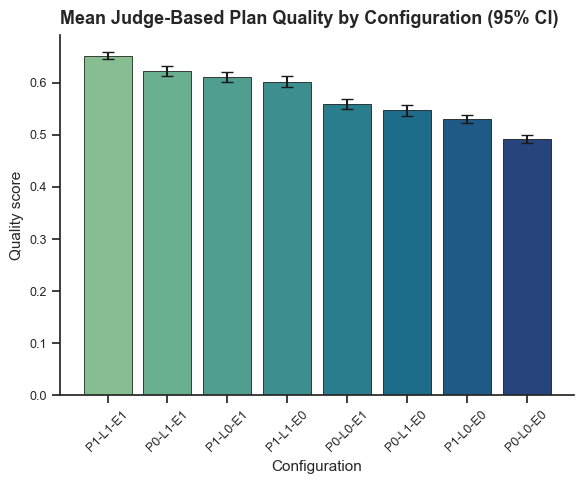

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.0)

fig, ax = plt.subplots(figsize=(6, 5))

ordered = summary_df.sort_values("quality_score", ascending=False)
bar_colors = sns.color_palette("crest", n_colors=len(ordered))

ax.bar(
    ordered["config_label"],
    ordered["quality_score"],
    yerr=ordered["quality_score_ci95"],
    capsize=4,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Mean Judge-Based Plan Quality by Configuration (95% CI)",
             fontsize=13, fontweight="bold", loc="left", pad=8)
ax.set_xlabel("Configuration", fontsize=11)
ax.set_ylabel("Quality score", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
kruskal_results_df, pairwise_config_results_df = nonparametric_config_tests(
    results_df,
    group_col="config_label",
    metric_col="quality_score",
    p_adjust="holm",
)

kruskal_results_df, pairwise_config_results_df.head(20)


(          metric  n_groups      kruskal_p
 0  quality_score         8  3.775134e-109,
     config_a  config_b  n_a  n_b  median_a  median_b  median_diff_a_minus_b  \
 0   P0-L0-E0  P1-L1-E1  150  150  0.483333  0.666667              -0.183333   
 1   P1-L0-E0  P1-L1-E1  150  150  0.500000  0.666667              -0.166667   
 2   P0-L0-E0  P0-L1-E1  150  150  0.483333  0.666667              -0.183333   
 3   P0-L0-E0  P1-L0-E1  150  150  0.483333  0.666667              -0.183333   
 4   P0-L0-E0  P1-L1-E0  150  150  0.483333  0.600000              -0.116667   
 5   P0-L1-E0  P1-L1-E1  150  150  0.500000  0.666667              -0.166667   
 6   P0-L0-E1  P1-L1-E1  150  150  0.566667  0.666667              -0.100000   
 7   P0-L1-E1  P1-L0-E0  150  150  0.666667  0.500000               0.166667   
 8   P1-L0-E0  P1-L0-E1  150  150  0.500000  0.666667              -0.166667   
 9   P0-L1-E0  P0-L1-E1  150  150  0.500000  0.666667              -0.166667   
 10  P0-L0-E0  P0-L0-E1  150  150

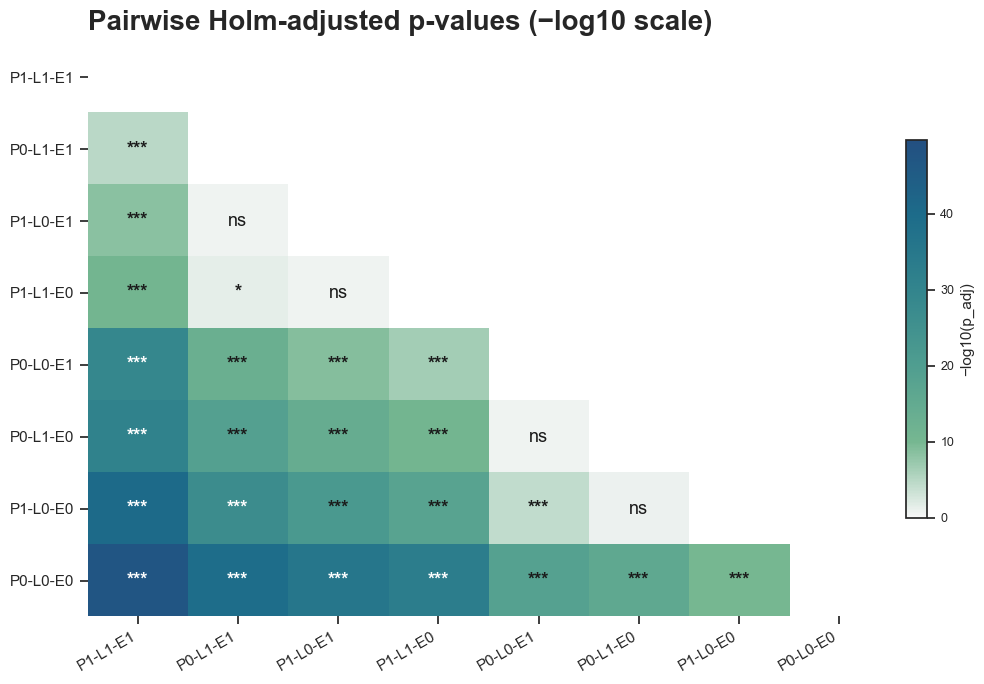

In [109]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="ticks", font_scale=1.0)

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# --- Build matrices ---
config_order = summary_df.sort_values("quality_score", ascending=False)["config_label"].tolist()
n_configs = len(config_order)
label_to_x = {label: i for i, label in enumerate(config_order)}

p_matrix = np.full((n_configs, n_configs), np.nan)

for row in pairwise_config_results_df.itertuples(index=False):
    i = label_to_x[row.config_a]
    j = label_to_x[row.config_b]
    p = float(row.p_adj)
    p_matrix[i, j] = p
    p_matrix[j, i] = p

with np.errstate(divide="ignore"):
    log_p = -np.log10(p_matrix)

# --- Lower triangle only (mask upper + diagonal) ---
lower_log_p = np.where(
    np.tril(np.ones((n_configs, n_configs), dtype=bool), k=-1),
    log_p,
    np.nan
)

# --- Colormap: derived from "crest" to stay on-palette ---
crest_colors = sns.color_palette("crest", n_colors=5).as_hex()
heat_cmap = LinearSegmentedColormap.from_list(
    "pval_heat", ["#F7F7F7"] + crest_colors, N=256
)
heat_cmap.set_bad(color="white")  # NaN cells (upper triangle + diagonal) → white

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    lower_log_p, cmap=heat_cmap, aspect="auto",
    vmin=0, vmax=np.nanmax(log_p) * 1.05,
    interpolation="nearest",
)

# --- Annotations (lower triangle only) ---
for i in range(n_configs):
    for j in range(n_configs):
        if j >= i:  # skip diagonal and upper triangle
            continue
        if np.isnan(p_matrix[i, j]):
            continue
        txt = p_to_stars(p_matrix[i, j])
        color = "white" if log_p[i, j] > np.nanmax(log_p) * 0.55 else "#1a1a1a"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=13, color=color,
                fontweight="bold" if txt != "ns" else "normal")

# --- Axes & labels ---
ax.set_xticks(range(n_configs))
ax.set_yticks(range(n_configs))
ax.set_xticklabels(config_order, fontsize=11, rotation=30, ha="right")
ax.set_yticklabels(config_order, fontsize=11)
ax.set_title(
    "Pairwise Holm-adjusted p-values (−log10 scale)",
    fontsize=20, fontweight="bold", pad=8, loc="left",
)

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, aspect=18)
cbar.set_label("−log10(p_adj)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()